In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
df= pd.read_csv('data/Financials.csv')
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
#Sütun isimlerindeki boşlukları silmek için
df.columns= df.columns.str.strip()

#Temizlenmesi gereken parasal sütunlsrı belirlemek için
para_sutunlari= ['Units Sold','Manufacturing Price','Sale Price','Gross Sales','Discounts','Sales','COGS','Profit']

#Temizliyoruz
for col in para_sutunlari:
    #Sütun zaten sayı tipindeyse(float veya int) dokunmadan atlasın diye)
    if pd.api.types.is_numeric_dtype(df[col]):
        continue
    
    #önce metne çevirerek karakterleri temizliyoruz
    df[col]= df[col].astype(str)
    df[col]= df[col].str.replace('$','',regex=False)
    df[col]= df[col].str.replace(',','',regex=False)
    df[col]= df[col].str.replace(')','',regex=False)
    df[col]= df[col].str.replace('(','-',regex=False)

    #Tekrardan sayıya (float) çeviriyoruz./ Hata verirse değeri NaN ile değiştir.
    df[col]= pd.to_numeric(df[col], errors='coerce')

#kontrol
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    object 
 1   Country              700 non-null    object 
 2   Product              700 non-null    object 
 3   Discount Band        700 non-null    object 
 4   Units Sold           700 non-null    float64
 5   Manufacturing Price  700 non-null    float64
 6   Sale Price           700 non-null    float64
 7   Gross Sales          700 non-null    float64
 8   Discounts            647 non-null    float64
 9   Sales                700 non-null    float64
 10  COGS                 700 non-null    float64
 11  Profit               695 non-null    float64
 12  Date                 700 non-null    object 
 13  Month Number         700 non-null    int64  
 14  Month Name           700 non-null    object 
 15  Year                 700 non-null    int

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
print(df.isnull().sum())

Segment                 0
Country                 0
Product                 0
Discount Band           0
Units Sold              0
Manufacturing Price     0
Sale Price              0
Gross Sales             0
Discounts              53
Sales                   0
COGS                    0
Profit                  5
Date                    0
Month Number            0
Month Name              0
Year                    0
dtype: int64


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
#sayısal sütunlardaki boşlukları MEDYAN ile dolduralım.
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col]= df[col].fillna(df[col].mode()[0])

#Metin sütunlarını en çok tekrar edenle(mod) ile dolduralım garanti olsun
for col in df.select_dtypes(include=['object']).columns:
    df[col]= df[col].fillna(df[col].mode()[0])

#kontrol
df.isnull().sum()

Segment                0
Country                0
Product                0
Discount Band          0
Units Sold             0
Manufacturing Price    0
Sale Price             0
Gross Sales            0
Discounts              0
Sales                  0
COGS                   0
Profit                 0
Date                   0
Month Number           0
Month Name             0
Year                   0
dtype: int64

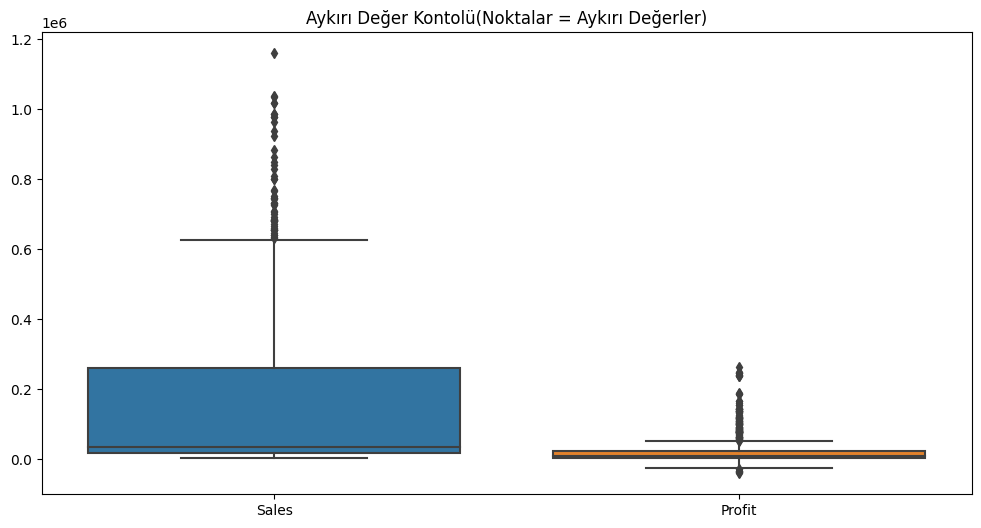

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
import matplotlib.pyplot as plt
import seaborn as sns

#grafik boyutlandırma
plt.figure(figsize=(12, 6))

#sales ve profit sütunları için grafik
sns.boxplot(data=df[['Sales', 'Profit']])
plt.title("Aykırı Değer Kontolü(Noktalar = Aykırı Değerler)")
plt.show()

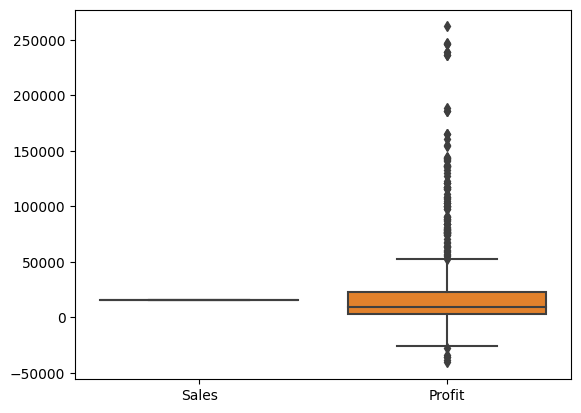

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
# Aykırı değerleri sınırlara eşitleyen fonksiyon
def aykiri_degerleri_baskila(df, sutun_listesi):
    for col in sutun_listesi:
        #çeyreklçeri hesapla
        Q1= df[col].quantile(0.25)
        Q3= df[col].quantile(0.25)
        IQR= Q3 - Q1

        #Alt ve Üst sınırları belirle
        alt_sinir= Q1 - 1.5*IQR
        ust_sinir= Q3 + 1.5*IQR

        #Sınırlardan taşanları(Aykırı değerleri) sınırlara eşitle
        df.loc[df[col]< alt_sinir,col]= alt_sinir
        df.loc[df[col]> ust_sinir,col]= ust_sinir

        return df

#Hangi sütunları düzelteceğiz?(sayısal olanlar)
duzeltilecekler= ['Sales','Units Sold','Profit', 'Gross Sales','COGS','Manufacturing Price']

#Fonksiyonu Çalıştır
df= aykiri_degerleri_baskila(df, duzeltilecekler)

#Aykırı değerler traşlandı yani absürt fazla veya az değerleri normale çektik.

#Tekrar grafiğe bakıp kontrol edelim
sns.boxplot(data=df[['Sales','Profit']])
plt.show()

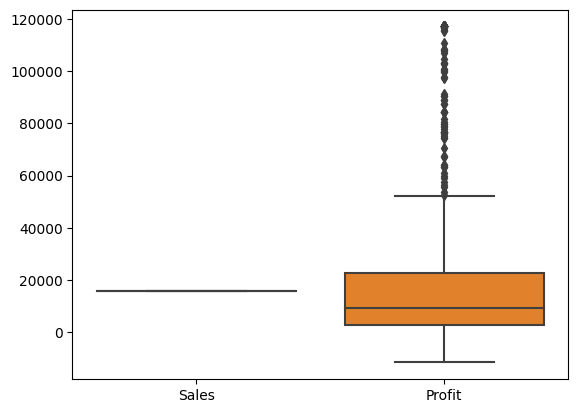

In [8]:
# --- [CELL 7]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
# === BEFORE (original) ===
# def kesin_tiraslama(df, sutun_listesi):
#     for col in sutun_listesi:
#         alt_sinir= df['Profit'].quantile(0.05)
#         ust_sinir= df['Profit'].quantile(0.95)
# 
#         #sınırların dışındaki değerleri çekelim
#         df['Profit']= df['Profit'].clip(lower=alt_sinir, upper=ust_sinir)
#         return df,
# 
# #Sütunları tekrar belirleyelim
# duzeltilecekler= ['Sales','Units Sold', 'Gross Sale','COGS','Manufacturing Price']
# 
# #Traşla
# df= kesin_tiraslama(df, duzeltilecekler)
# 
# #grafiğe bakalım
# sns.boxplot(data=df[['Sales','Profit']])
# plt.show()

# === AFTER (edited) ===
def kesin_tiraslama(df, sutun_listesi):
    for col in sutun_listesi:
        alt_sinir= df['Profit'].quantile(0.05)
        ust_sinir= df['Profit'].quantile(0.95)


        df['Profit']= df['Profit'].clip(lower=alt_sinir, upper=ust_sinir)
        return df

duzeltilecekler= ['Sales','Units Sold', 'Gross Sales','COGS','Manufacturing Price']


df= kesin_tiraslama(df, duzeltilecekler)


sns.boxplot(data=df[['Sales','Profit']])
plt.show()

In [9]:
import pandas as pd
import numpy as np

# 1) Crash regression: df must remain a DataFrame (not tuple)
assert isinstance(df, pd.DataFrame), "df should be a DataFrame after kesin_tiraslama"

# 2) Function contract: must return DataFrame
result = kesin_tiraslama(df.copy(), ["Sales", "Profit"])
assert isinstance(result, pd.DataFrame), "kesin_tiraslama should return a DataFrame"

# 3) Full-column clipping check for all target columns
duzeltilecekler = ["Sales", "Units Sold", "Gross Sales", "COGS", "Manufacturing Price"]

outlier_df = df[duzeltilecekler].copy()
for i, col in enumerate(duzeltilecekler):
    idx = outlier_df.index[i % len(outlier_df)]
    outlier_df.loc[idx, col] = outlier_df[col].max() * 100

clipped_all = kesin_tiraslama(outlier_df.copy(), duzeltilecekler)

for col in duzeltilecekler:
    assert clipped_all[col].max() < outlier_df[col].max(), f"{col} outlier should be clipped"

# 4) Parameter-respect behavior: clipping only Sales should not change other columns
control_df = df[["Sales", "Profit"]].copy()
control_df.loc[control_df.index[0], "Sales"] = control_df["Sales"].max() * 100

clipped_sales_only = kesin_tiraslama(control_df.copy(), ["Sales"])

assert clipped_sales_only["Sales"].max() < control_df["Sales"].max(), "Sales should be clipped when requested"
assert clipped_sales_only["Profit"].equals(control_df["Profit"]), "Profit should remain unchanged if not requested"

# 5) Column-name regression from fix: Gross Sales must be accepted (no KeyError)
_ = kesin_tiraslama(df.copy(), ["Sales", "Units Sold", "Gross Sales", "COGS", "Manufacturing Price"])

KeyError: 'Profit'